In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt
import h5py
import os
import tqdm
import scipy
from scipy import signal
import pickle
from tqdm import tnrange
from tqdm import tqdm

import seaborn as sns
from scipy.stats import norm,entropy,linregress
from scipy.optimize import minimize, curve_fit
from scipy.io import savemat
from scipy.special import erf
import sys
import warnings
import odor_breathing_functions
import functions_beh

warnings.filterwarnings('ignore')

cmap = plt.rcParams['axes.prop_cycle'].by_key()['color']
modulename = 'multiprocess'
mpl.rcParams['svg.fonttype'] = 'none'
sns.set_context('poster', font_scale=1.1)

In [2]:
from collections import defaultdict
from scipy.signal import spectrogram
import numpy as np

def group_and_pad_by_date(subject_breathing_list):
    """
    Combine breathing trials by date, padding to each date's max trial length.

    Parameters
    ----------
    subject_breathing_list : list of (date, breathing_array) tuples
        Each breathing_array is 2D (trials x time).

    Returns
    -------
    grouped : dict
        Keys = dates, values = arrays (trials x max_len_for_that_date)
    """
    grouped = {}

    # Group by date
    for date, arr in subject_breathing_list:
        if date not in grouped:
            grouped[date] = []
        grouped[date].append(arr)

    # Pad per date
    padded_grouped = {}
    for date, arrays in grouped.items():
        # print(date, len(arrays))
        max_len = max(a.shape[1] for a in arrays)  # max trial length for this date
        padded_arrays = []
        for a in arrays:
            pad_width = max_len - a.shape[1]
            if pad_width > 0:
                a_padded = np.pad(a, ((0,0), (0,pad_width)), mode="constant")
            else:
                a_padded = a
            padded_arrays.append(a_padded)
        padded_grouped[date] = np.concatenate(padded_arrays, axis=0)

    return padded_grouped

In [3]:
breathing_learning = np.load('breathing_learning.npy', allow_pickle=True)
breathing_learning_list = breathing_learning.tolist()

In [4]:
spec_list = []
dominant_freq_list = []
time_varying_dom_list = []

for i in range(len(breathing_learning_list)):
    # --- Group and pad trials per date for this subject ---
    grouped_by_date = group_and_pad_by_date(breathing_learning_list[i])

    spectrograms = []
    dominant_freq = []
    time_varying_dom = []

    # --- Compute spectrogram per date ---
    for date, all_trials in grouped_by_date.items():  
        # all_trials shape: (n_trials, max_len_for_this_date)

        Sxx_trials = []
        for trial in all_trials:
            f, t, Sxx = spectrogram(trial, fs=1000, nperseg=2000, noverlap=1000)
            Sxx_trials.append(Sxx)

        # Average across trials
        Sxx_mean = np.mean(Sxx_trials, axis=0)

        # Save full spectrogram
        spectrograms.append((date, f, t, Sxx_mean))

        # --- Global dominant frequency (across all time bins) ---
        mean_power = np.mean(Sxx_mean, axis=1)
        dom_freq_val = f[np.argmax(mean_power)]
        dominant_freq.append([date, dom_freq_val])

        # --- Time-varying dominant frequency (per time bin) ---
        dom_freq_time = f[np.argmax(Sxx_mean, axis=0)]
        time_varying_dom.append((date, dom_freq_time))

    # Save results per subject
    spec_list.append(spectrograms)
    dominant_freq_list.append(np.array(dominant_freq))
    time_varying_dom_list.append(time_varying_dom)

{1: (np.float64(0.7450980392156863), np.float64(0.6823529411764706), np.float64(0.8313725490196079), np.float64(1.0)), 2: (np.float64(0.9921568627450981), np.float64(0.7529411764705882), np.float64(0.5254901960784314), np.float64(1.0)), 3: (np.float64(1.0), np.float64(1.0), np.float64(0.6), np.float64(1.0)), 4: (np.float64(0.2196078431372549), np.float64(0.4235294117647059), np.float64(0.6901960784313725), np.float64(1.0)), 5: (np.float64(0.9411764705882353), np.float64(0.00784313725490196), np.float64(0.4980392156862745), np.float64(1.0)), 6: (np.float64(0.7490196078431373), np.float64(0.3568627450980392), np.float64(0.09019607843137253), np.float64(1.0)), 7: (np.float64(0.4), np.float64(0.4), np.float64(0.4), np.float64(1.0))}
0 [['20220128' '3.0']
 ['20220201' '3.5']
 ['20220202' '3.5']
 ['20220203' '3.0']
 ['20220204' '3.5']
 ['20220205' '3.5']
 ['20220206' '3.0']
 ['20220207' '3.0']
 ['20220208' '3.0']
 ['20220209' '3.5']
 ['20220211' '3.5']
 ['20220212' '3.5']
 ['20220213' '3.0']

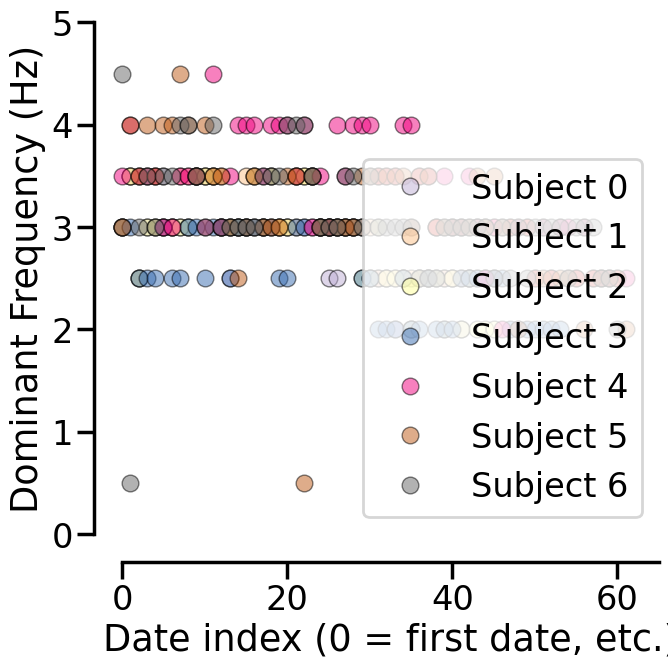

In [5]:
cmap = plt.get_cmap("Accent")

# Suppose subj_idx goes from 1 to N
N = 7  # number of subjects
colors = [cmap(i) for i in np.linspace(0, 1, N+2)][1:-1]  
# → gives N evenly spaced colors between start and end of cmap

# Now assign each subject a fixed color
subject_colors = {subj_idx: colors[i] for i, subj_idx in enumerate(range(1, N+1))}

print(subject_colors)
plt. figure(figsize=(7,7))
for subj_idx, subj_dom in enumerate(dominant_freq_list):
    print(subj_idx, subj_dom)
    # subj_dom[:,0] is the date (or date index)
    sorted_idx = np.argsort(subj_dom[:,0].astype(int))  # sort numerically by date
    #print(sorted)
    x_vals = np.arange(len(subj_dom))  # 0,1,2,...
    y_vals = subj_dom[sorted_idx, 1].astype(float)  # dominant frequency values sorted by date
    #print(type(y_vals[0]))  # dominant frequency

    plt.plot(x_vals, y_vals, 'o', label=f"Subject {subj_idx}", color = subject_colors[subj_idx+1], markeredgecolor='k', clip_on=False, alpha=0.5)

plt.xlabel("Date index (0 = first date, etc.)")
plt.ylabel("Dominant Frequency (Hz)")
#plt.title("Dominant Frequency per Session (Global)")
plt.ylim(0, 5)
plt.xlim(0,65)
#plt.grid(True)
plt.legend()
plt.tight_layout()
sns.despine(offset=20)
#plt.savefig('dom_breathing_freq_across_training.svg', format ='svg', transparent=True, bbox_inches='tight')

plt.show()

In [6]:
import pandas as pd

rows = []
for group_idx, group in enumerate(dominant_freq_list):
    # group is a NumPy array of rows
    for arr in group:
        # arr is a 1D NumPy array of fields (strings, numbers, etc.)
        rows.append([group_idx] + arr.tolist())

df_dom_freq_across_learning = pd.DataFrame(rows)

with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    df_dom_freq_across_learning.to_excel(writer, sheet_name="Supp_Figure_2A", index=False)


In [7]:
breathing_testing = np.load('breathing_testing.npy', allow_pickle=True)
breathing_testing_list = breathing_testing.tolist()

In [8]:
spec_list = []
dominant_freq_list = []
time_varying_dom_list = []

for i in range(len(breathing_testing_list)):
    # --- Group and pad trials per date for this subject ---
    grouped_by_date = group_and_pad_by_date(breathing_testing_list[i])

    spectrograms = []
    dominant_freq = []
    time_varying_dom = []

    # --- Compute spectrogram per date ---
    for date, all_trials in grouped_by_date.items():  
        # all_trials shape: (n_trials, max_len_for_this_date)

        Sxx_trials = []
        for trial in all_trials:
            f, t, Sxx = spectrogram(trial, fs=1000, nperseg=1000, noverlap=0)
            Sxx_trials.append(Sxx)

        # Average across trials
        Sxx_mean = np.mean(Sxx_trials, axis=0)

        # Save full spectrogram
        #spectrograms.append((date, f, t, Sxx_trials))
        spectrograms.append(Sxx_trials)

        # --- Global dominant frequency (across all time bins) ---
        mean_power = np.mean(Sxx_mean, axis=1)
        dom_freq_val = f[np.argmax(mean_power)]
        dominant_freq.append([date, dom_freq_val])

        # --- Time-varying dominant frequency (per time bin) ---
        dom_freq_time = f[np.argmax(Sxx_mean, axis=0)]
        time_varying_dom.append((date, dom_freq_time))

    # Save results per subject
    spec_list.append(spectrograms)
    dominant_freq_list.append(np.array(dominant_freq))
    time_varying_dom_list.append(time_varying_dom)

all_arrays = [
    arr
    for subj in spec_list        # outermost list
    for session in subj          # middle list
    for arr in session           # each element is already an ndarray
]

stacked = np.stack(all_arrays, axis=0)

print(stacked.shape)

(19388, 501, 10)


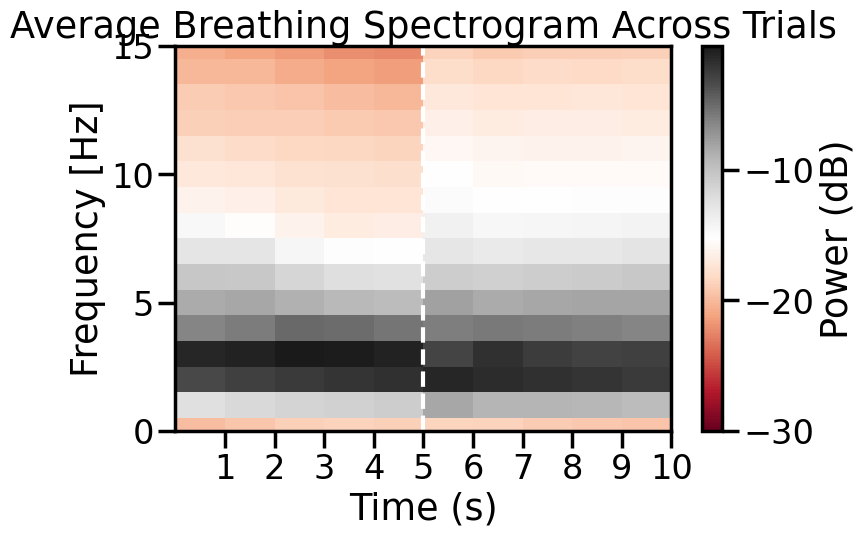

In [9]:
plt.figure(figsize=(8,5))
plt.pcolormesh(t, f, 10*np.log10(np.mean(stacked, axis=0)), shading='nearest', cmap=sns.color_palette("RdGy", as_cmap=True), vmin=-30, rasterized=True)
plt.ylim(0, 15)
plt.colorbar(label='Power (dB)')
plt.xlabel('Time (s)')
plt.xticks(t+0.5)
plt.vlines(5,0,15,color='white',linestyle='--')
plt.ylabel('Frequency [Hz]')
plt.title('Average Breathing Spectrogram Across Trials')
#plt.vlines(6,0,15,color='white',linestyle='--')

#plt.savefig('spectrogram_all_animals.svg', format='svg', transparent=True, bbox_inches='tight')

plt.show()

In [14]:
S_db = 10 * np.log10(np.mean(stacked, axis=0))  # (n_freq, n_time)

df_wide = pd.DataFrame(
    S_db,
    index=f,   # frequency axis
    columns=t  # time axis
)

df_wide.index.name = "frequency"
df_wide.columns = [f"time_{ti:.6f}" for ti in t]  # optional: nicer column names

with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    df_wide.to_excel(writer, sheet_name="Supp_Figure_2B", index=False)